# Task 4 - Sentiment Analysis

## Objective

Build a machine learning model that classifies Twitter text into Positive, Negative, and Neutral sentiments.

## Technologies Used

- Python
- Pandas
- NumPy
- NLTK
- Scikit-learn
- Matplotlib
- Seaborn
- WordCloud
- Jupyter Notebook

## Dataset

The project uses a Twitter Sentiment Analysis dataset containing Twitter posts, their associated entities, and sentiment labels.

The original dataset contained four sentiment categories: Positive, Negative, Neutral, and Irrelevant. Since the project objective focuses on three sentiment classes, the Irrelevant class was removed before model training.

## Machine Learning Workflow

1. Load and inspect the dataset
2. Analyze sentiment distribution
3. Clean and preprocess text
4. Extract TF-IDF features
5. Split the data into training and testing sets
6. Train Multinomial Naive Bayes
7. Train Logistic Regression
8. Evaluate both models
9. Visualize sentiment distribution
10. Generate sentiment-specific WordClouds
11. Perform error analysis
12. Compare model performance
13. Select the best-performing model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "data/twitter_training.csv",
    encoding="latin1",
    header=None
)

print(df.shape)
print(df.columns)
print(df.head())

(74682, 4)
Index([0, 1, 2, 3], dtype='int64')
      0            1         2  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                   3  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [2]:
df.columns = ["id", "entity", "sentiment", "text"]

print(df.columns)

Index(['id', 'entity', 'sentiment', 'text'], dtype='str')


In [3]:
print(df["sentiment"].value_counts())

sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         74682 non-null  int64
 1   entity     74682 non-null  str  
 2   sentiment  74682 non-null  str  
 3   text       73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.3 MB


In [5]:
df.isnull().sum()

id             0
entity         0
sentiment      0
text         686
dtype: int64

In [6]:
df["sentiment"].value_counts()

sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In [7]:
(df["sentiment"].value_counts(normalize=True) * 100).round(2)

sentiment
Negative      30.18
Positive      27.89
Neutral       24.53
Irrelevant    17.39
Name: proportion, dtype: float64

In [8]:
# Remove Irrelevant sentiment
df = df[df["sentiment"] != "Irrelevant"].copy()

# Remove rows with missing text or sentiment
df.dropna(subset=["text", "sentiment"], inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print("Dataset after cleaning:")
print("Shape:", df.shape)
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Dataset after cleaning:
Shape: (61121, 4)

Sentiment distribution:
sentiment
Negative    22358
Positive    20655
Neutral     18108
Name: count, dtype: int64


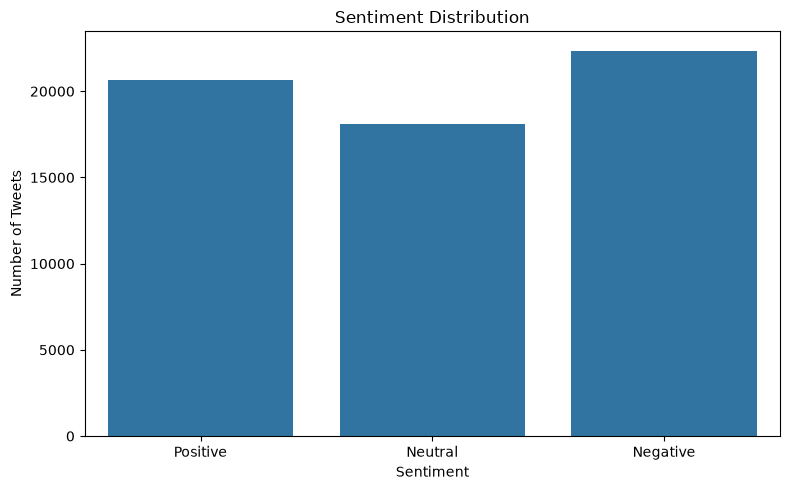

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="sentiment")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()

In [5]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("NLTK resources ready!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kishw\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kishw\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kishw\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kishw\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\kishw\AppData\Roaming\nltk_data...


NLTK resources ready!


In [10]:
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove mentions and hashtags
    text = re.sub(r"@\w+|#\w+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Tokenization
    tokens = word_tokenize(text)

    # Stopword removal
    tokens = [
        word for word in tokens
        if word.isalpha() and word not in stop_words
    ]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

print("Preprocessing function created successfully!")

Preprocessing function created successfully!


In [11]:
sample_text = df["text"].iloc[0]

print("Original:")
print(sample_text)

print("\nPreprocessed:")
print(preprocess_text(sample_text))

Original:
im getting on borderlands and i will murder you all ,

Preprocessed:
im getting borderland murder


In [12]:
# Apply preprocessing to all tweets
df["clean_text"] = df["text"].apply(preprocess_text)

print("Text preprocessing completed!")

Text preprocessing completed!


In [13]:
df[["text", "clean_text"]].head(10)

,text,clean_text
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland murder
5,im getting into borderlands and i can murder y...,im getting borderland murder
6,So I spent a few hours making something for fu...,spent hour making something fun dont know huge...
7,So I spent a couple of hours doing something f...,spent couple hour something fun dont know im h...
8,So I spent a few hours doing something for fun...,spent hour something fun dont know im huge bor...
9,So I spent a few hours making something for fu...,spent hour making something fun dont know huge...


In [14]:
df = df[df["clean_text"].str.strip() != ""].copy()

df.reset_index(drop=True, inplace=True)

print("Dataset shape after removing empty texts:", df.shape)

Dataset shape after removing empty texts: (59597, 5)


### TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical features that can be used by machine learning algorithms.

- **TF (Term Frequency):** Measures how frequently a word appears in a document.
- **IDF (Inverse Document Frequency):** Gives lower importance to words that appear in many documents and higher importance to words that are more unique.
- **TF-IDF:** Combines TF and IDF to assign importance to words in the dataset.

TF-IDF is useful for sentiment analysis because it represents important words numerically while reducing the influence of very common words.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df["clean_text"])

print("TF-IDF feature extraction completed!")
print("Feature matrix shape:", X.shape)

TF-IDF feature extraction completed!
Feature matrix shape: (59597, 10000)


In [16]:
from sklearn.model_selection import train_test_split

# Target variable
y = df["sentiment"]

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training data shape: (47677, 10000)
Testing data shape: (11920, 10000)
Training labels: (47677,)
Testing labels: (11920,)


In [17]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes model trained successfully!")
print("Number of predictions:", len(y_pred_nb))

Naive Bayes model trained successfully!
Number of predictions: 11920


In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", round(nb_accuracy, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.759

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.84      0.79      4376
     Neutral       0.79      0.61      0.69      3517
    Positive       0.75      0.80      0.78      4027

    accuracy                           0.76     11920
   macro avg       0.76      0.75      0.75     11920
weighted avg       0.76      0.76      0.76     11920



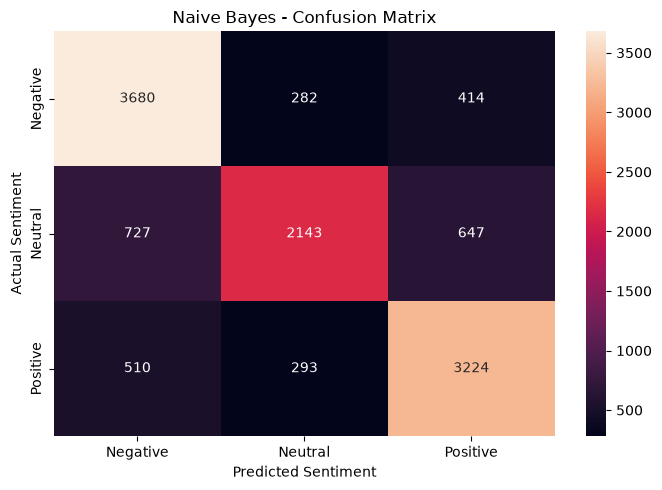

In [19]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=["Negative", "Neutral", "Positive"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

In [20]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression model trained successfully!")
print("Number of predictions:", len(y_pred_lr))

Logistic Regression model trained successfully!
Number of predictions: 11920


In [21]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", round(lr_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8003

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.85      0.83      4376
     Neutral       0.79      0.71      0.75      3517
    Positive       0.80      0.82      0.81      4027

    accuracy                           0.80     11920
   macro avg       0.80      0.80      0.80     11920
weighted avg       0.80      0.80      0.80     11920



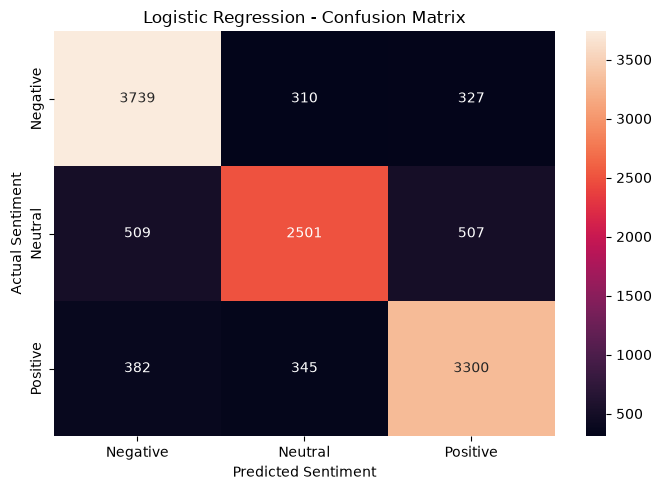

In [22]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=["Negative", "Neutral", "Positive"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

In [23]:
# Get Naive Bayes metrics
nb_report = classification_report(
    y_test,
    y_pred_nb,
    output_dict=True
)

# Get Logistic Regression metrics
lr_report = classification_report(
    y_test,
    y_pred_lr,
    output_dict=True
)

# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        nb_report["accuracy"],
        lr_report["accuracy"]
    ],
    "Precision": [
        nb_report["weighted avg"]["precision"],
        lr_report["weighted avg"]["precision"]
    ],
    "Recall": [
        nb_report["weighted avg"]["recall"],
        lr_report["weighted avg"]["recall"]
    ],
    "F1-Score": [
        nb_report["weighted avg"]["f1-score"],
        lr_report["weighted avg"]["f1-score"]
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.7590,0.7616,0.7590,0.7556
1,Logistic Regression,0.8003,0.8000,0.8003,0.7992


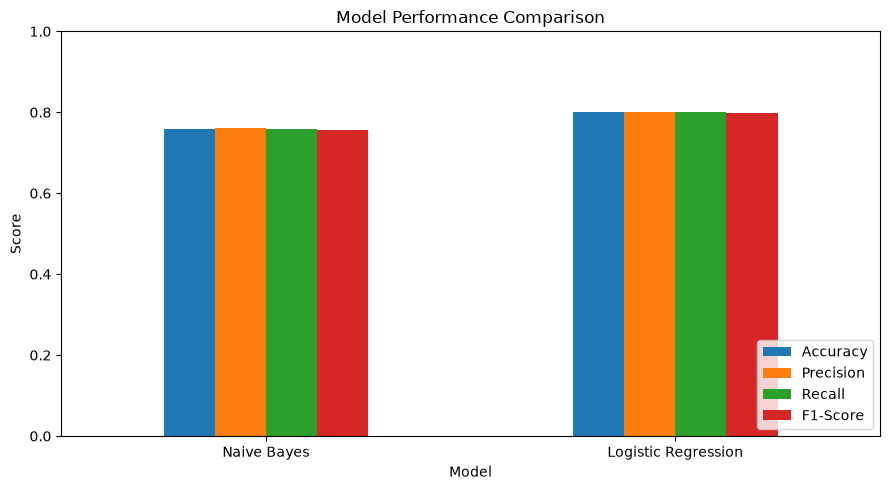

In [32]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

print("WordCloud imported successfully!")

WordCloud imported successfully!


In [27]:
def generate_wordcloud(sentiment):
    text = " ".join(
        df[df["sentiment"] == sentiment]["clean_text"]
    )

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=100
    ).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Most Common Words - {sentiment} Sentiment")
    plt.show()

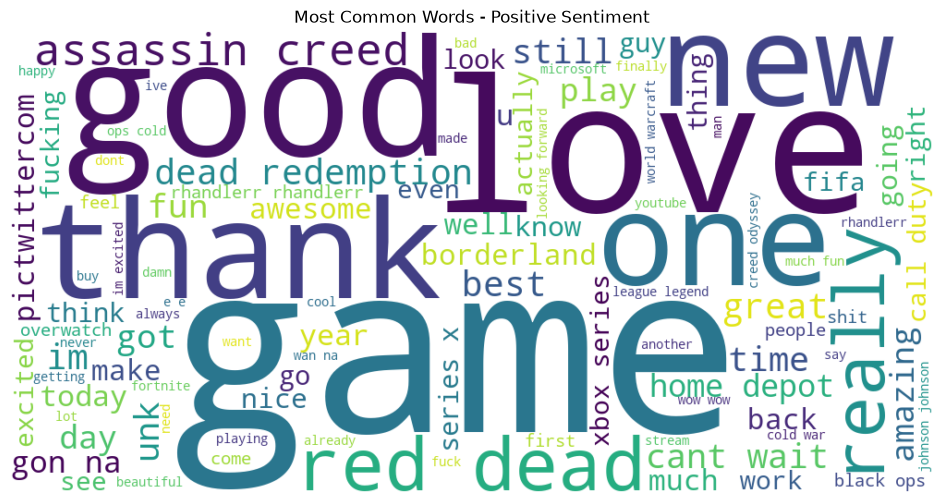

In [28]:
generate_wordcloud("Positive")

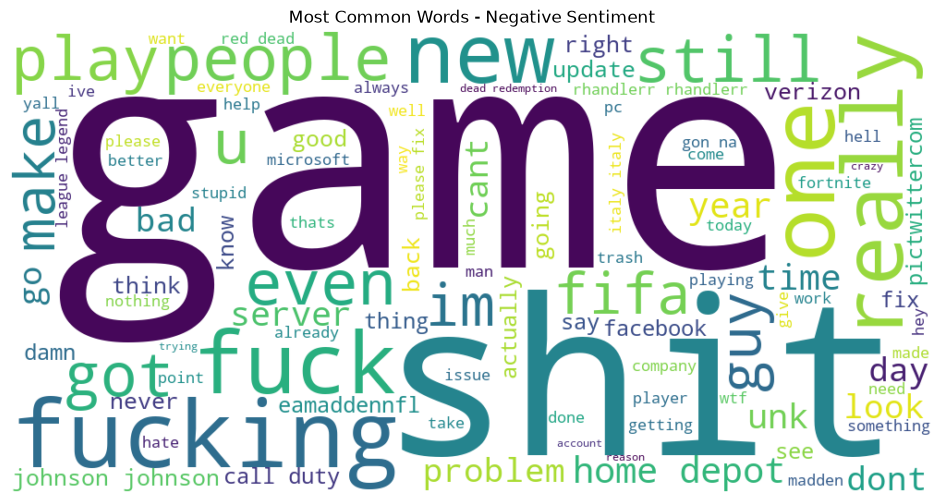

In [29]:
generate_wordcloud("Negative")

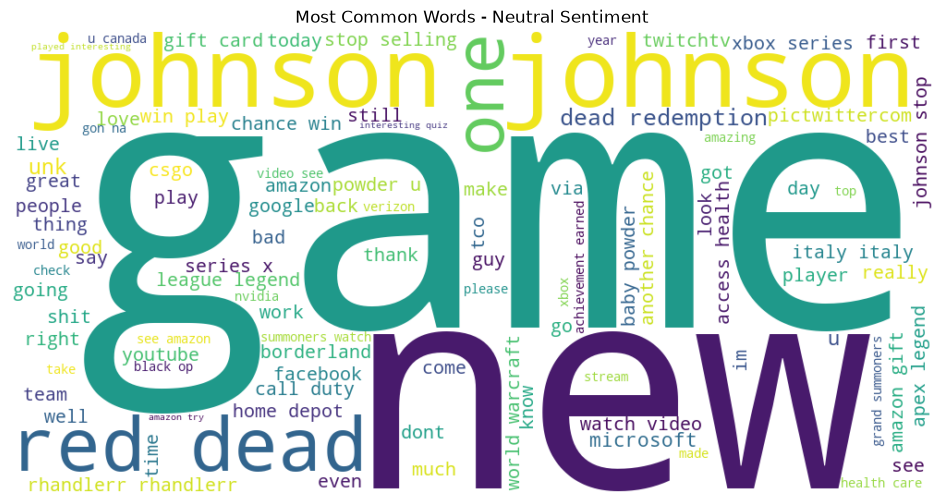

In [30]:
generate_wordcloud("Neutral")

In [31]:
# Find misclassified examples
misclassified = df.loc[
    y_test.index[y_test != y_pred_lr],
    ["text", "sentiment"]
].copy()

# Add predicted sentiment
misclassified["predicted_sentiment"] = y_pred_lr[y_test != y_pred_lr]

# Display 5 examples
misclassified.head(5)

,text,sentiment,predicted_sentiment
57225,Ghost Story breakpoint.. for.playstation.com/,Neutral,Negative
21716,I'm especially digging this new gold insignia!,Positive,Neutral
22669,The trailer is dropping in around an hour and ...,Positive,Neutral
49296,Get in here and support a good friend!,Positive,Neutral
46864,The best thing I couldâve sacrificed for my,Negative,Positive


In [35]:
# Display final model comparison
comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.7590,0.7616,0.7590,0.7556
1,Logistic Regression,0.8003,0.8000,0.8003,0.7992


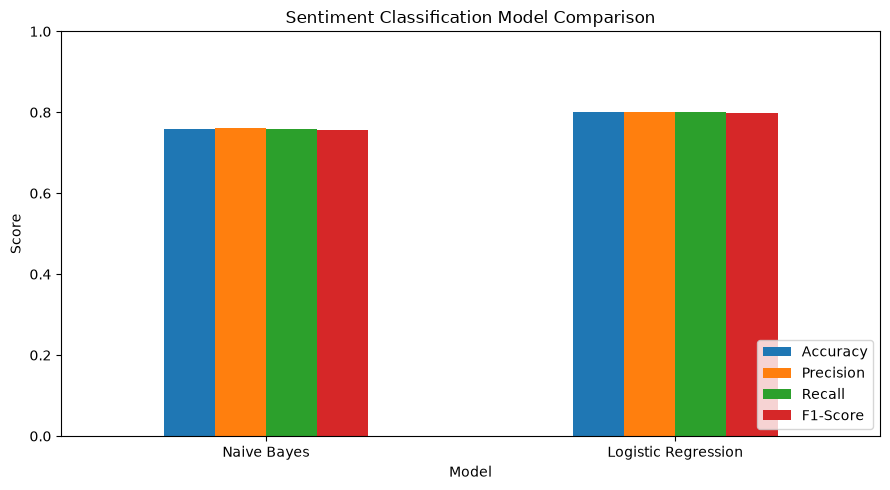

In [36]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Sentiment Classification Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [37]:
best_model = comparison.loc[
    comparison["F1-Score"].idxmax(),
    "Model"
]

best_f1 = comparison["F1-Score"].max()

print("Best Model:", best_model)
print("Best F1-Score:", round(best_f1, 4))

Best Model: Logistic Regression
Best F1-Score: 0.7992


## Conclusion

This project developed a machine learning-based sentiment analysis system for classifying Twitter text into Positive, Negative, and Neutral sentiments.

The text data was cleaned using lowercase conversion, URL and punctuation removal, stopword removal, tokenization, and lemmatization. TF-IDF was then used to convert the processed text into numerical features suitable for machine learning.

Two classification algorithms were trained and evaluated: Multinomial Naive Bayes and Logistic Regression. Their performance was compared using accuracy, precision, recall, F1-score, and confusion matrices.

The model with the highest F1-score was selected as the best-performing model. The results demonstrate that traditional machine learning techniques combined with TF-IDF can effectively classify sentiment in social media text.

### Real-World Applications

Sentiment analysis can be used for:

- Customer feedback analysis
- Brand reputation monitoring
- Social media opinion analysis
- Product review analysis
- Customer service improvement
- Market research
- Public opinion monitoring

### Limitations

The model may struggle with sarcasm, slang, abbreviations, mixed emotions, and context-dependent statements. These factors can cause some tweets to be incorrectly classified.

## Final Results

The trained models were evaluated using accuracy, precision, recall, and F1-score.

The model comparison shows the relative performance of Multinomial Naive Bayes and Logistic Regression on the Twitter sentiment classification task.

The best model was selected based on its weighted F1-score, as F1-score provides a balance between precision and recall across the three sentiment classes.

The final system demonstrates that TF-IDF-based machine learning models can provide an effective baseline for sentiment analysis of social media text.